#PART 1 — VAE (Latent Space Visualization)

##Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

##Data

In [2]:
transform = transforms.ToTensor()

dataset = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
loader = DataLoader(dataset, batch_size=128, shuffle=True)

##VAE Model

In [3]:
class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc_mu = nn.Linear(256, 2)
        self.fc_logvar = nn.Linear(256, 2)
        self.fc2 = nn.Linear(2, 256)
        self.fc3 = nn.Linear(256, 784)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparam(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std

    def decode(self, z):
        h = torch.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparam(mu, logvar)
        return self.decode(z), mu, logvar

##Train VAE

In [4]:
model = VAE()
opt = optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(5):
    for x,_ in loader:
        x = x.view(-1,784)
        recon, mu, logvar = model(x)

        recon_loss = nn.functional.binary_cross_entropy(recon, x, reduction="sum")
        kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        loss = recon_loss + kl

        opt.zero_grad()
        loss.backward()
        opt.step()

##Latent Space Plot

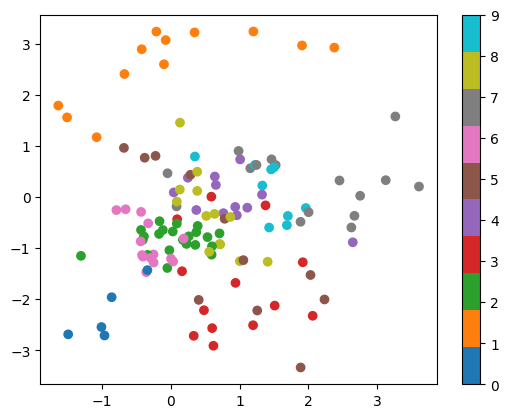

In [5]:
z_list = []
labels = []

with torch.no_grad():
    for x,y in loader:
        x = x.view(-1,784)
        mu,_ = model.encode(x)
        z_list.append(mu)
        labels.append(y)
        break

z = torch.cat(z_list).numpy()
labels = torch.cat(labels).numpy()

plt.scatter(z[:,0], z[:,1], c=labels, cmap="tab10")
plt.colorbar()
plt.show()

#PART 2 — GAN (Image Synthesis)

##Generator & Discriminator

In [6]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(100,256),
            nn.ReLU(),
            nn.Linear(256,784),
            nn.Tanh()
        )

    def forward(self,z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784,256),
            nn.LeakyReLU(0.2),
            nn.Linear(256,1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.net(x)

##Train GAN

In [7]:
G = Generator()
D = Discriminator()

opt_g = optim.Adam(G.parameters(), lr=1e-3)
opt_d = optim.Adam(D.parameters(), lr=1e-3)
criterion = nn.BCELoss()

for epoch in range(5):
    for x,_ in loader:
        x = x.view(-1,784)

        real = torch.ones(x.size(0),1)
        fake = torch.zeros(x.size(0),1)

        # D
        z = torch.randn(x.size(0),100)
        fake_imgs = G(z)

        loss_d = criterion(D(x), real) + criterion(D(fake_imgs.detach()), fake)

        opt_d.zero_grad()
        loss_d.backward()
        opt_d.step()

        # G
        loss_g = criterion(D(fake_imgs), real)

        opt_g.zero_grad()
        loss_g.backward()
        opt_g.step()

##Generate Images

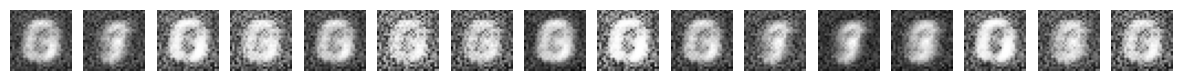

In [8]:
z = torch.randn(16,100)
imgs = G(z).view(-1,1,28,28).detach()

fig, ax = plt.subplots(1,16, figsize=(15,2))
for i in range(16):
    ax[i].imshow(imgs[i][0], cmap="gray")
    ax[i].axis("off")
plt.show()

#PART 3 — GCN (Citation Network)

##Imports

In [9]:
!pip install torch-geometric

import torch
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv

##Load Data

In [10]:
dataset = Planetoid(root="./data", name="Cora")
data = dataset[0]

##GCN Model

In [11]:
class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(dataset.num_features, 16)
        self.conv2 = GCNConv(16, dataset.num_classes)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

##Train GCN

In [12]:
model = GCN()
opt = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(100):
    out = model(data)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])

    opt.zero_grad()
    loss.backward()
    opt.step()

##Accuracy

In [13]:
pred = model(data).argmax(dim=1)
correct = (pred[data.test_mask] == data.y[data.test_mask]).sum()
acc = int(correct) / int(data.test_mask.sum())

print("Accuracy:", acc)

Accuracy: 0.77
